#Import packages


In [37]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from tqdm.notebook import  tqdm
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
import torchvision
import matplotlib.pyplot as plt


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Get the dataset

In [ ]:
data = torchvision.datasets.FashionMNIST(root='data', download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.43MB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 17.9MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
print(data.train_data.shape)
print(data.train_labels.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


#The model


In [38]:
class AlexNet(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()
        self.convBlock = nn.Sequential(
            nn.LazyConv2d(16, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2))
            # nn.Flatten(),
        self.fullConnected = nn.Sequential(
            nn.LazyLinear(512), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(512), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes),
            nn.Softmax(dim=1))
    def forward(self, X):
        x = self.convBlock(X)
        x = x.reshape(x.shape[0], -1)
        x = self.fullConnected(x)
        return x

We [**construct a single-channel data example**] with both height and width of 224 (**to observe the output shape of each layer**). It matches the AlexNet architecture in :numref:`fig_alexnet`.


In [40]:
model = AlexNet()
print(model)


AlexNet(
  (convBlock): Sequential(
    (0): LazyConv2d(0, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): LazyConv2d(0, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): LazyConv2d(0, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): LazyConv2d(0, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fullConnected): Sequential(
    (0): LazyLinear(in_features=0, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): LazyLinear(in_features=0, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): LazyLinear(in_features=0, out_features=10, bias=True)
    (7): Softmax(dim=1)
  )
)


In [41]:
loss_fun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0002)

#Dataset


In [42]:
x = data.train_data.float()
x = x.reshape(-1, 1, 28, 28)
print(x.shape)
x /= torch.max(x)
XTrain, XTest, yTrain, yTest = train_test_split(x, data.train_labels, test_size=0.04, random_state=12345)
trainDL = DataLoader(TensorDataset(XTrain, yTrain), batch_size=64, shuffle=True)
valDL = DataLoader(TensorDataset(XTest, yTest), batch_size=len(yTest), shuffle=True)

torch.Size([60000, 1, 28, 28])


In [44]:
model.eval()
X, y= next(iter(trainDL))
print(X.shape)
print(y.shape)
model = model.to(device)
X = X.to(device)
print(model(X))
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

torch.Size([64, 1, 28, 28])
torch.Size([64])
tensor([[0.0956, 0.0952, 0.1021, 0.1001, 0.1027, 0.1012, 0.1012, 0.1017, 0.1052,
         0.0950],
        [0.0955, 0.0953, 0.1020, 0.1002, 0.1025, 0.1014, 0.1012, 0.1018, 0.1050,
         0.0951],
        [0.0956, 0.0951, 0.1022, 0.1001, 0.1027, 0.1011, 0.1012, 0.1016, 0.1052,
         0.0952],
        [0.0956, 0.0952, 0.1022, 0.1003, 0.1026, 0.1013, 0.1011, 0.1016, 0.1051,
         0.0950],
        [0.0956, 0.0953, 0.1020, 0.1002, 0.1025, 0.1014, 0.1012, 0.1018, 0.1050,
         0.0951],
        [0.0956, 0.0952, 0.1021, 0.1001, 0.1025, 0.1012, 0.1013, 0.1017, 0.1050,
         0.0951],
        [0.0955, 0.0953, 0.1021, 0.1003, 0.1023, 0.1015, 0.1013, 0.1018, 0.1049,
         0.0950],
        [0.0957, 0.0952, 0.1021, 0.1002, 0.1026, 0.1012, 0.1011, 0.1018, 0.1050,
         0.0950],
        [0.0956, 0.0953, 0.1022, 0.1002, 0.1024, 0.1014, 0.1011, 0.1017, 0.1051,
         0.0950],
        [0.0956, 0.0952, 0.1022, 0.1002, 0.1024, 0.1014, 0.1011,

#Training model

In [ ]:
def weights_init(m):
    if type(m) == nn.Conv2d or type(m) == nn.Linear:
        torch.nn.init.xavier_uniform(m.weight.data)
def train_the_model(model, loss_fun, optimizer, epochs = 10):
    model = model.to(device)
    # init with xavier method
    model.apply(weights_init)
    train_loss = torch.zeros(epochs)
    test_loss = torch.zeros(epochs)
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)

    for epoch_i in tqdm(range(epochs)):
        batch_loss = []
        batch_acc = []

        model.train()
        for X, y in tqdm(trainDL):
            X, y = X.to(device), y.to(device)

            y_hat = model(X)
            loss = loss_fun(y_hat, torch.squeeze(y))
            batch_loss.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            acc = torch.mean((torch.argmax(y_hat, axis=1) == y).float()).item()
            batch_acc.append(acc)

        train_acc[epoch_i] = np.mean(batch_acc)
        train_loss[epoch_i] = np.mean(batch_loss)

        model.eval()
        X, y = next(iter(valDL))
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            y_hat = model(X)
            loss = loss_fun(y_hat, torch.squeeze(y))
            acc = torch.mean((torch.argmax(y_hat, axis=1) == y).float()).item()

            test_acc[epoch_i] = acc
            test_loss[epoch_i] = loss.item()

    return train_loss, test_loss, train_acc, test_acc, model

In [ ]:
train_loss, test_loss, train_acc, test_acc, model =  train_the_model(model, loss_fun, optimizer, 20)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

...

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

  0%|          | 0/900 [00:00<?, ?it/s]

#Visualize loss and accuracy

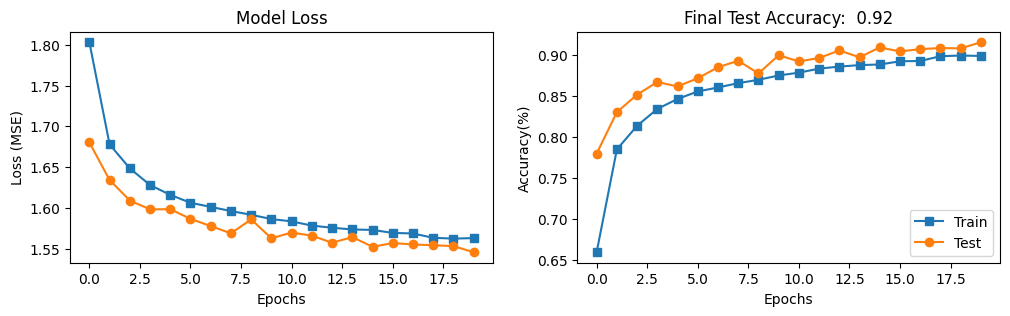

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

ax[0].plot(train_loss, "s-", label="Train")
ax[0].plot(test_loss, "o-", label="Test")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss (MSE)")
ax[0].set_title("Model Loss")

ax[1].plot(train_acc, "s-", label="Train")
ax[1].plot(test_acc, "o-", label="Test")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy(%)")
ax[1].set_title(f"Final Test Accuracy: {test_acc[-1]: 0.2f}")
ax[1].legend()
plt.show()

#Visualize some images

In [ ]:
xTest = data.test_data.float()
xTest = xTest.reshape(-1, 1, 28, 28)
xTest /= torch.max(xTest)
yTest = data.test_labels
print(yTest.shape)
testDl = DataLoader(TensorDataset(xTest, yTest), batch_size=128, shuffle=True)
def accuracy(model, testDL):
    numAcc = 0
    for x, yTrue in testDL:
        model.eval()
        x = x.to(device)
        yPred = model(x)
        yPred = torch.argmax(yPred, axis=1)
        yPred = yPred.cpu()
        numAcc += torch.sum(yPred == yTrue).item()
    return numAcc / len(testDL.dataset)

torch.Size([60000])


In [ ]:
print(accuracy(model, testDl))

0.91045


In [ ]:
print(data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


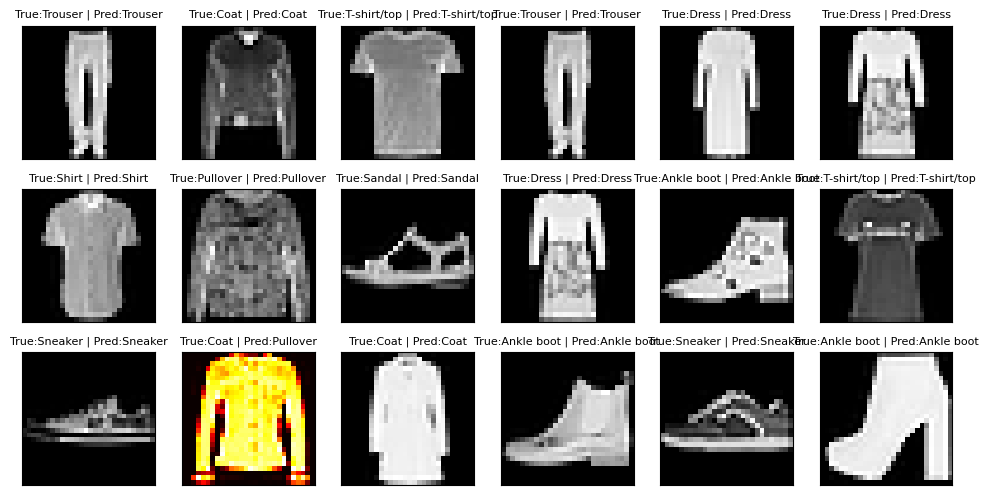

In [ ]:
fig, axs = plt.subplots(3, 6, figsize=(12, 6))
x, y = next(iter(testDl))
for i, ax in enumerate(axs.flatten()):
    idx = np.random.randint(0, len(y))
    yPred = model(x[idx:idx+1, :, :, :].to(device))
    image = np.squeeze(x[idx, 0, :, :]).cpu()
    yPred = torch.argmax(yPred, axis=1)
    yPred = yPred.cpu()
    yTrue = y[idx]
    cmap = "hot" if yPred != yTrue else "gray"
    ax.imshow(image, cmap=cmap)
    ax.set_title(f"True:{data.classes[yTrue]} | Pred:{data.classes[yPred]}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])


In [ ]:
torch.save(model.state_dict(), "parameters.pt")
torch.save({
            'epoch': 20,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss_fun,
            }, "checkPoint.pt")